In [1]:
import cv2
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

from lightglue import SuperPoint
from lightglue import LightGlue
from lightglue.utils import load_image
from lightglue.utils import rbd

device = (
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print("Device:", device)

Device: cuda


In [2]:
DATASET_ROOT = Path(
    r"E:\Nordland Dataset\nordland-part-2020\nordland-part-2020"
)

SUMMER_DIR = DATASET_ROOT / "summer"
WINTER_DIR = DATASET_ROOT / "winter"


In [3]:
summer_images = sorted(
    list(SUMMER_DIR.glob("*.png"))
)

winter_images = sorted(
    list(WINTER_DIR.glob("*.png"))
)

print("Summer:", len(summer_images))
print("Winter:", len(winter_images))

Summer: 1750
Winter: 1750


In [4]:
extractor = (
    SuperPoint(
        max_num_keypoints=4096
    )
    .eval()
    .to(device)
)

matcher = (
    LightGlue(
        features="superpoint"
    )
    .eval()
    .to(device)
)

print("Models Loaded")

Models Loaded


In [5]:
WARP_DIR = Path(
    "outputs/warped"
)

WARP_DIR.mkdir(
    parents=True,
    exist_ok=True
)

print("Warp Folder Ready")

Warp Folder Ready


In [41]:
def estimate_homography(
    summer_img,
    winter_img
):

    image0 = load_image(
        str(summer_img)
    ).to(device)

    image1 = load_image(
        str(winter_img)
    ).to(device)

    feats0 = extractor.extract(image0)
    feats1 = extractor.extract(image1)

    matches01 = matcher({
        "image0": feats0,
        "image1": feats1
    })

    feats0, feats1, matches01 = [
        rbd(x)
        for x in [
            feats0,
            feats1,
            matches01
        ]
    ]

    matches = matches01["matches"]

    points0 = (
        feats0["keypoints"]
        [matches[:,0]]
        .cpu()
        .numpy()
    )

    points1 = (
        feats1["keypoints"]
        [matches[:,1]]
        .cpu()
        .numpy()
    )

    H, mask = cv2.findHomography(
    points0,
    points1,
    cv2.USAC_MAGSAC,
    2.0
    )
    if H is None:
        raise Exception(
            "Homography Failed"
        )

    return H, mask, points0, points1

In [42]:
selected_frames = [
    250,
    625,
    1600,
    1625
]


In [43]:
idx = 250

H, mask, pts0, pts1 = estimate_homography(
    summer_images[idx],
    winter_images[idx]
)

print("Homography Matrix:\n")
print(H)

Homography Matrix:

[[ 9.70635063e-01 -4.30783343e-02  1.58954827e-01]
 [ 4.06156382e-03  9.67197892e-01 -6.00001886e+00]
 [-4.85501922e-05 -1.24459239e-04  1.00000000e+00]]


In [44]:
def warp_image(
    summer_img,
    winter_img,
    H
):

    summer = cv2.imread(
        str(summer_img)
    )

    winter = cv2.imread(
        str(winter_img)
    )

    h, w = winter.shape[:2]

    warped = cv2.warpPerspective(
        summer,
        H,
        (w, h)
    )

    return summer, winter, warped

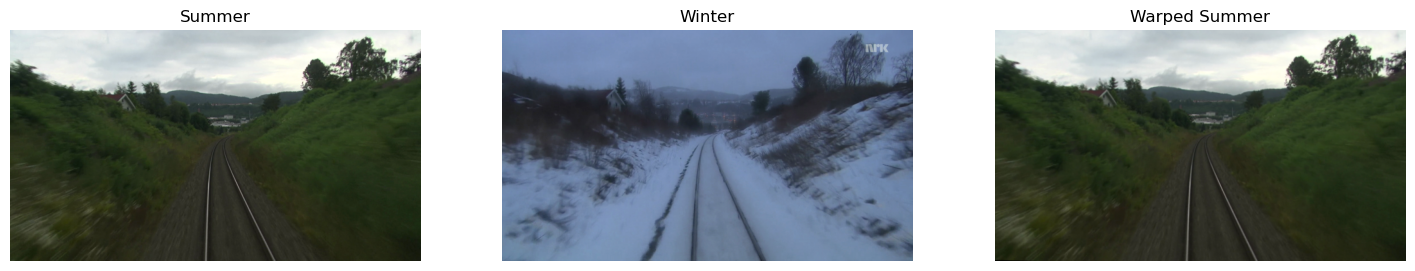

In [45]:
summer, winter, warped = warp_image(
    summer_images[250],
    winter_images[250],
    H
)

plt.figure(figsize=(18,6))

plt.subplot(1,3,1)
plt.imshow(
    cv2.cvtColor(
        summer,
        cv2.COLOR_BGR2RGB
    )
)
plt.title("Summer")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(
    cv2.cvtColor(
        winter,
        cv2.COLOR_BGR2RGB
    )
)
plt.title("Winter")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(
    cv2.cvtColor(
        warped,
        cv2.COLOR_BGR2RGB
    )
)
plt.title("Warped Summer")
plt.axis("off")

plt.show()



In [46]:
def create_overlay(
    warped,
    winter
):

    overlay = cv2.addWeighted(
        warped,
        0.5,
        winter,
        0.5,
        0
    )

    return overlay

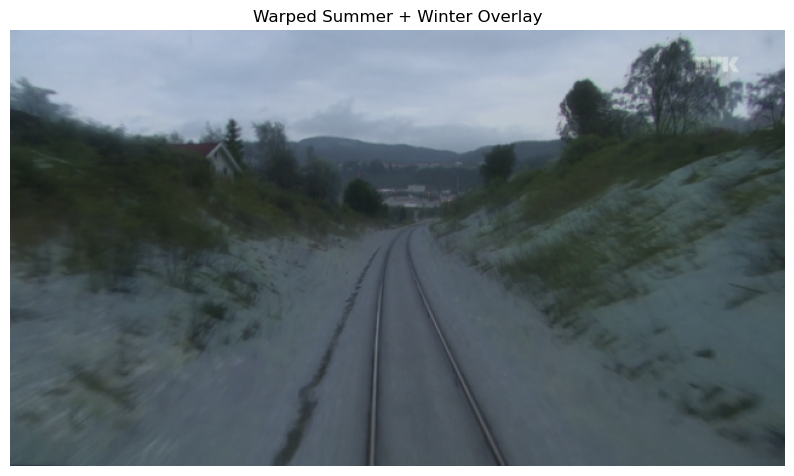

In [47]:
overlay = create_overlay(
    warped,
    winter
)

plt.figure(figsize=(10,8))

plt.imshow(
    cv2.cvtColor(
        overlay,
        cv2.COLOR_BGR2RGB
    )
)

plt.title(
    "Warped Summer + Winter Overlay"
)

plt.axis("off")

plt.show()


In [48]:
def reprojection_error(
    H,
    pts0,
    pts1,
    mask
):

    mask = mask.ravel().astype(bool)

    pts0 = pts0[mask]
    pts1 = pts1[mask]

    projected = cv2.perspectiveTransform(
        pts0.reshape(-1,1,2),
        H
    ).reshape(-1,2)

    error = np.mean(
        np.linalg.norm(
            projected - pts1,
            axis=1
        )
    )

    return float(error)

In [49]:
results = []

for idx in selected_frames:

    try:

        H, mask, pts0, pts1 = (
            estimate_homography(
                summer_images[idx],
                winter_images[idx]
            )
        )

        summer, winter, warped = (
            warp_image(
                summer_images[idx],
                winter_images[idx],
                H
            )
        )

        overlay = create_overlay(
            warped,
            winter
        )

        cv2.imwrite(
            str(
                WARP_DIR /
                f"warp_{idx}.png"
            ),
            overlay
        )

        error = reprojection_error(
    H,
    pts0,
    pts1,
    mask
         )

        results.append([
            idx,
            round(error,2)
        ])

        print(
            f"Saved Frame {idx}"
        )

    except Exception as e:

        print(
            idx,
            e
        )
        

Saved Frame 250
Saved Frame 625
Saved Frame 1600
Saved Frame 1625


In [53]:
df = pd.DataFrame(
    results,
    columns=[
        "Frame",
        "Reprojection Error"
    ]
)
df

,Frame,Reprojection Error
0,250,1.25
1,625,1.00
2,1600,0.94
3,1625,0.27


In [54]:
df.to_csv(
    "outputs/homography_results.csv",
    index=False
)

print(
    "Homography Results Saved"
)

Homography Results Saved


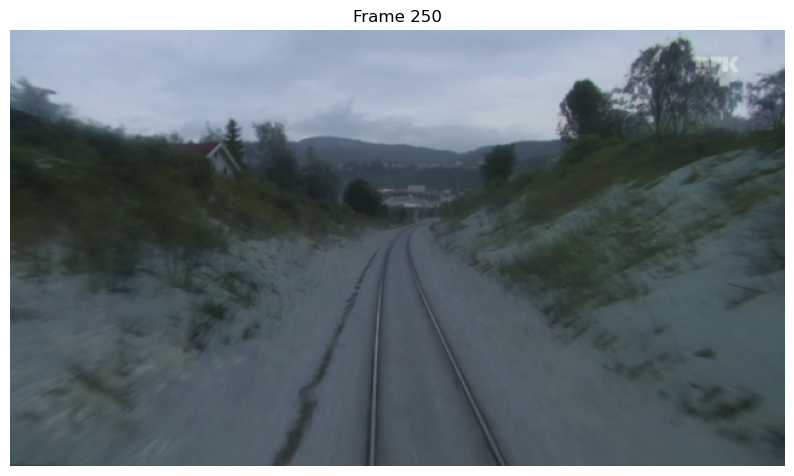

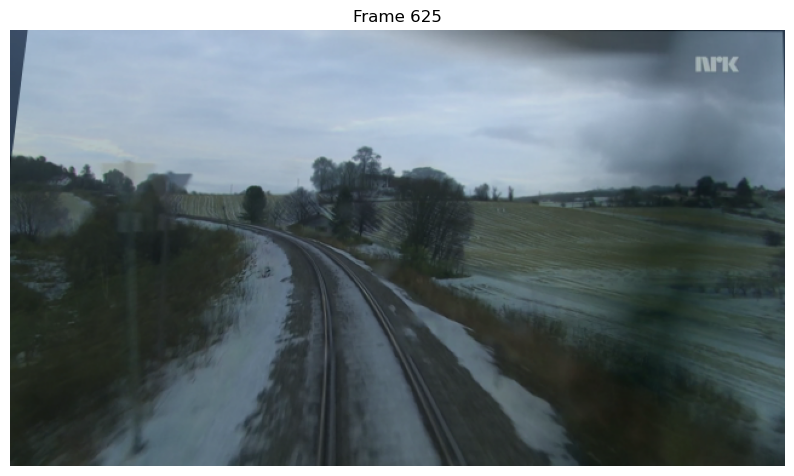

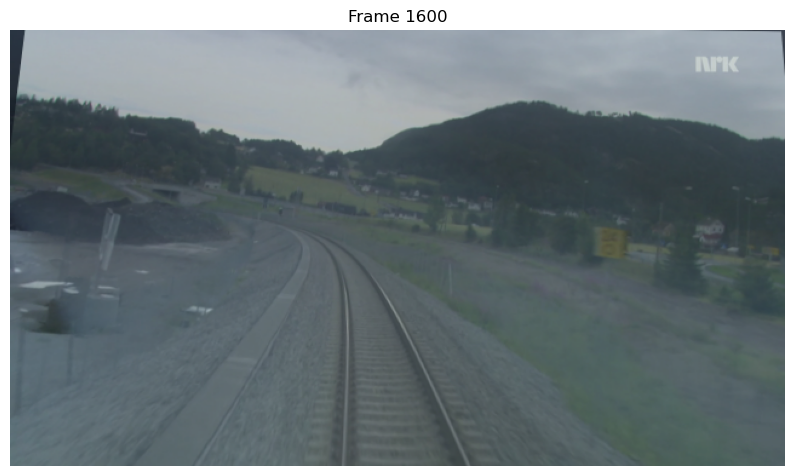

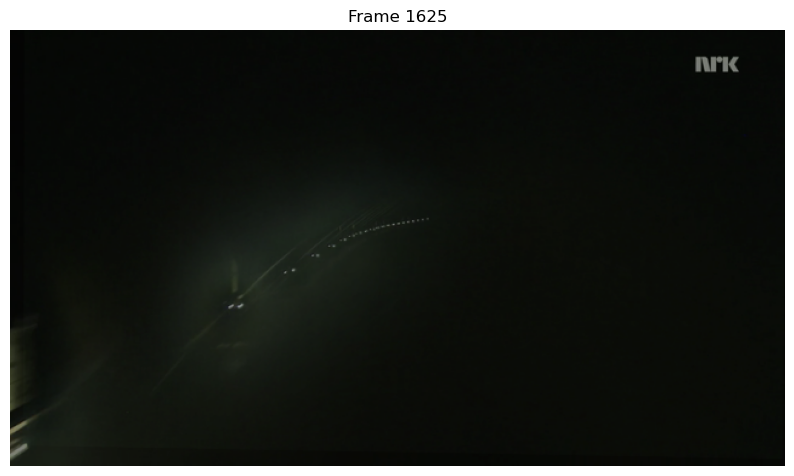

In [55]:
for idx in selected_frames:

    img = cv2.imread(
        str(
            WARP_DIR /
            f"warp_{idx}.png"
        )
    )

    img = cv2.cvtColor(
        img,
        cv2.COLOR_BGR2RGB
    )

    plt.figure(figsize=(10,6))
    plt.imshow(img)
    plt.title(
        f"Frame {idx}"
    )
    plt.axis("off")
    plt.show()